In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
%matplotlib inline

In [ ]:
df = pd.read_csv('CarPrice_Assignment.csv')

In [ ]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [ ]:
df.tail()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0
204,205,-1,volvo 264gl,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625.0


In [ ]:
df["symboling"].unique()

array([ 3,  1,  2,  0, -1, -2])

In [ ]:
corr_price_symboling = df["price"].corr(df["symboling"])
print("Price ile Symboling korelasyonu:", corr_price_symboling)

Price ile Symboling korelasyonu: -0.07997822464270347


In [ ]:
df["CarName"].unique()

array(['alfa-romero giulia', 'alfa-romero stelvio',
       'alfa-romero Quadrifoglio', 'audi 100 ls', 'audi 100ls',
       'audi fox', 'audi 5000', 'audi 4000', 'audi 5000s (diesel)',
       'bmw 320i', 'bmw x1', 'bmw x3', 'bmw z4', 'bmw x4', 'bmw x5',
       'chevrolet impala', 'chevrolet monte carlo', 'chevrolet vega 2300',
       'dodge rampage', 'dodge challenger se', 'dodge d200',
       'dodge monaco (sw)', 'dodge colt hardtop', 'dodge colt (sw)',
       'dodge coronet custom', 'dodge dart custom',
       'dodge coronet custom (sw)', 'honda civic', 'honda civic cvcc',
       'honda accord cvcc', 'honda accord lx', 'honda civic 1500 gl',
       'honda accord', 'honda civic 1300', 'honda prelude',
       'honda civic (auto)', 'isuzu MU-X', 'isuzu D-Max ',
       'isuzu D-Max V-Cross', 'jaguar xj', 'jaguar xf', 'jaguar xk',
       'maxda rx3', 'maxda glc deluxe', 'mazda rx2 coupe', 'mazda rx-4',
       'mazda glc deluxe', 'mazda 626', 'mazda glc', 'mazda rx-7 gs',
       'mazda glc 

In [ ]:
# CarName kolonundan sadece marka kısmını çek
df['brand'] = df['CarName'].apply(lambda x: x.split()[0].lower())

In [ ]:
df["brand"].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [ ]:
# Marka temizleme için mapping
brand_mapping = {
    'toyouta': 'toyota',
    'porcshce': 'porsche',
    'vw': 'volkswagen',
    'vokswagen': 'volkswagen',
    'maxda': 'mazda'
}

df['brand'] = df['brand'].replace(brand_mapping)

In [ ]:
df["brand"].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab',
       'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

In [ ]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [ ]:
df["fueltype"].unique()  # label encoding

array(['gas', 'diesel'], dtype=object)

In [ ]:
# fueltype: 'gas' → 0, 'diesel' → 1
df['fueltype_binary'] = df['fueltype'].map({'gas': 0, 'diesel': 1})

In [ ]:
df['fueltype_binary'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 205 entries, 0 to 204
Series name: fueltype_binary
Non-Null Count  Dtype
--------------  -----
205 non-null    int64
dtypes: int64(1)
memory usage: 1.7 KB


In [ ]:
df["aspiration"].unique() # label encoding

array(['std', 'turbo'], dtype=object)

In [ ]:
# aspiration: 'std' → 0, 'turbo' → 1
df['aspiration_binary'] = df['aspiration'].map({'std': 0, 'turbo': 1})

In [ ]:
df['aspiration_binary'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 205 entries, 0 to 204
Series name: aspiration_binary
Non-Null Count  Dtype
--------------  -----
205 non-null    int64
dtypes: int64(1)
memory usage: 1.7 KB


In [ ]:
df["doornumber"].unique()

array(['two', 'four'], dtype=object)

In [ ]:
df['doornumber_num'] = df['doornumber'].map({'two': 2, 'four': 4})  # kapı numaralarını sayısal yapalım.

In [ ]:
df['doornumber_num'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 205 entries, 0 to 204
Series name: doornumber_num
Non-Null Count  Dtype
--------------  -----
205 non-null    int64
dtypes: int64(1)
memory usage: 1.7 KB


In [ ]:
df['doornumber_num'].unique()

array([2, 4])

In [ ]:
# Korelasyon
corr = df['doornumber_num'].corr(df['price'])
print("Doornumber vs Price korelasyonu:", corr)

Doornumber vs Price korelasyonu: 0.031835265845609785


In [ ]:
# doornumber: 'two' → 0, 'four' → 1
df['doornumber_binary'] = df['doornumber'].map({'two': 0, 'four': 1})

In [ ]:
df['doornumber_binary'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 205 entries, 0 to 204
Series name: doornumber_binary
Non-Null Count  Dtype
--------------  -----
205 non-null    int64
dtypes: int64(1)
memory usage: 1.7 KB


In [ ]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,horsepower,peakrpm,citympg,highwaympg,price,brand,doornumber_num,doornumber_binary,fueltype_binary,aspiration_binary
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,111,5000,21,27,13495.0,alfa-romero,2,0,0,0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,111,5000,21,27,16500.0,alfa-romero,2,0,0,0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,154,5000,19,26,16500.0,alfa-romero,2,0,0,0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,102,5500,24,30,13950.0,audi,4,1,0,0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,115,5500,18,22,17450.0,audi,4,1,0,0


In [ ]:
df["carbody"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 205 entries, 0 to 204
Series name: carbody
Non-Null Count  Dtype 
--------------  ----- 
205 non-null    object
dtypes: object(1)
memory usage: 1.7+ KB


In [ ]:
df["carbody"].unique()

array(['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop'],
      dtype=object)

In [ ]:
df = pd.get_dummies(df, columns=['carbody'], drop_first=True)

In [ ]:
df["drivewheel"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 205 entries, 0 to 204
Series name: drivewheel
Non-Null Count  Dtype 
--------------  ----- 
205 non-null    object
dtypes: object(1)
memory usage: 1.7+ KB


In [ ]:
df["drivewheel"].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [ ]:
df = pd.get_dummies(df, columns=['drivewheel'], drop_first=True)

In [ ]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,enginelocation,wheelbase,carlength,carwidth,...,doornumber_num,doornumber_binary,fueltype_binary,aspiration_binary,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_fwd,drivewheel_rwd
0,1,3,alfa-romero giulia,gas,std,two,front,88.6,168.8,64.1,...,2,0,0,0,False,False,False,False,False,True
1,2,3,alfa-romero stelvio,gas,std,two,front,88.6,168.8,64.1,...,2,0,0,0,False,False,False,False,False,True
2,3,1,alfa-romero Quadrifoglio,gas,std,two,front,94.5,171.2,65.5,...,2,0,0,0,False,True,False,False,False,True
3,4,2,audi 100 ls,gas,std,four,front,99.8,176.6,66.2,...,4,1,0,0,False,False,True,False,True,False
4,5,2,audi 100ls,gas,std,four,front,99.4,176.6,66.4,...,4,1,0,0,False,False,True,False,False,False


In [ ]:
df["enginelocation"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 205 entries, 0 to 204
Series name: enginelocation
Non-Null Count  Dtype 
--------------  ----- 
205 non-null    object
dtypes: object(1)
memory usage: 1.7+ KB


In [ ]:
df["enginelocation"].unique()

array(['front', 'rear'], dtype=object)

In [ ]:
df['enginelocation_binary'] = df['enginelocation'].map({'front': 0, 'rear': 1})

In [ ]:
# Wheelbase ile price korelasyonu
corr = df['wheelbase'].corr(df['price'])
print("Wheelbase vs Price korelasyonu:", corr)

Wheelbase vs Price korelasyonu: 0.5778155982921496


In [ ]:
df['wheelbase'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 205 entries, 0 to 204
Series name: wheelbase
Non-Null Count  Dtype  
--------------  -----  
205 non-null    float64
dtypes: float64(1)
memory usage: 1.7 KB


In [ ]:
# carlength ile price korelasyonu
corr = df['carlength'].corr(df['price'])
print("carlength vs Price korelasyonu:", corr)

carlength vs Price korelasyonu: 0.6829200156779629


In [ ]:
df['carlength'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 205 entries, 0 to 204
Series name: carlength
Non-Null Count  Dtype  
--------------  -----  
205 non-null    float64
dtypes: float64(1)
memory usage: 1.7 KB


In [ ]:
# carwidth ile price korelasyonu
corr = df['carwidth'].corr(df['price'])
print("carwidth vs Price korelasyonu:", corr)

carwidth vs Price korelasyonu: 0.7593252997415118


In [ ]:
df['carwidth'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 205 entries, 0 to 204
Series name: carwidth
Non-Null Count  Dtype  
--------------  -----  
205 non-null    float64
dtypes: float64(1)
memory usage: 1.7 KB


In [ ]:
# carheight ile price korelasyonu
corr = df['carheight'].corr(df['price'])
print("carheight vs Price korelasyonu:", corr)

carheight vs Price korelasyonu: 0.11933622657049436


In [ ]:
# curbweight ile price korelasyonu
corr = df['curbweight'].corr(df['price'])
print("curbweight vs Price korelasyonu:", corr)

curbweight vs Price korelasyonu: 0.8353048793372965


In [ ]:
df['curbweight'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 205 entries, 0 to 204
Series name: curbweight
Non-Null Count  Dtype
--------------  -----
205 non-null    int64
dtypes: int64(1)
memory usage: 1.7 KB


In [ ]:
df["enginetype"].unique()

array(['dohc', 'ohcv', 'ohc', 'l', 'rotor', 'ohcf', 'dohcv'], dtype=object)

In [ ]:
df = pd.get_dummies(df, columns=['enginetype'], drop_first=True)

In [ ]:
df["cylindernumber"].unique()

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

In [ ]:
# Mapping ile sayısal değer atama
cylinder_map = {
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12
}

df['cylindernumber_num'] = df['cylindernumber'].map(cylinder_map)

In [ ]:
df["fuelsystem"].unique()

array(['mpfi', '2bbl', 'mfi', '1bbl', 'spfi', '4bbl', 'idi', 'spdi'],
      dtype=object)

In [ ]:
df = pd.get_dummies(df, columns=['fuelsystem'], drop_first=True)

In [ ]:
other_numeric_values = {
    'enginesize','boreratio','stroke','compressionratio','horsepower','peakrpm','citympg','highwaympg'
}

In [ ]:
for col in other_numeric_values:
    corr = df[col].corr(df['price'])
    print(f"{col} vs Price korelasyonu: {corr}")

compressionratio vs Price korelasyonu: 0.06798350579944265
stroke vs Price korelasyonu: 0.079443083881931
citympg vs Price korelasyonu: -0.6857513360270401
horsepower vs Price korelasyonu: 0.8081388225362212
enginesize vs Price korelasyonu: 0.8741448025245112
boreratio vs Price korelasyonu: 0.5531732367984434
highwaympg vs Price korelasyonu: -0.6975990916465566
peakrpm vs Price korelasyonu: -0.08526715027785685


In [ ]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'enginelocation', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'cylindernumber', 'enginesize', 'boreratio',
       'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg',
       'highwaympg', 'price', 'brand', 'doornumber_num', 'doornumber_binary',
       'fueltype_binary', 'aspiration_binary', 'carbody_hardtop',
       'carbody_hatchback', 'carbody_sedan', 'carbody_wagon', 'drivewheel_fwd',
       'drivewheel_rwd', 'enginelocation_binary', 'enginetype_dohcv',
       'enginetype_l', 'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv',
       'enginetype_rotor', 'cylindernumber_num', 'fuelsystem_2bbl',
       'fuelsystem_4bbl', 'fuelsystem_idi', 'fuelsystem_mfi',
       'fuelsystem_mpfi', 'fuelsystem_spdi', 'fuelsystem_spfi'],
      dtype='object')

In [ ]:
df.drop(columns=['CarName', 'car_ID'], inplace=True)

In [ ]:
binary_cols_to_drop = ['doornumber', 'fueltype', 'aspiration', 'enginelocation']
df.drop(columns=binary_cols_to_drop, inplace=True)

In [ ]:
df.drop(columns=['doornumber_num'], inplace=True)

In [ ]:
df.head()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,...,enginetype_ohcv,enginetype_rotor,cylindernumber_num,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,3,88.6,168.8,64.1,48.8,2548,four,130,3.47,2.68,...,False,False,4,False,False,False,False,True,False,False
1,3,88.6,168.8,64.1,48.8,2548,four,130,3.47,2.68,...,False,False,4,False,False,False,False,True,False,False
2,1,94.5,171.2,65.5,52.4,2823,six,152,2.68,3.47,...,True,False,6,False,False,False,False,True,False,False
3,2,99.8,176.6,66.2,54.3,2337,four,109,3.19,3.40,...,False,False,4,False,False,False,False,True,False,False
4,2,99.4,176.6,66.4,54.3,2824,five,136,3.19,3.40,...,False,False,5,False,False,False,False,True,False,False


In [ ]:
df = pd.get_dummies(df, columns=['brand'], drop_first=True)

In [ ]:
df.head()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,...,brand_nissan,brand_peugeot,brand_plymouth,brand_porsche,brand_renault,brand_saab,brand_subaru,brand_toyota,brand_volkswagen,brand_volvo
0,3,88.6,168.8,64.1,48.8,2548,four,130,3.47,2.68,...,False,False,False,False,False,False,False,False,False,False
1,3,88.6,168.8,64.1,48.8,2548,four,130,3.47,2.68,...,False,False,False,False,False,False,False,False,False,False
2,1,94.5,171.2,65.5,52.4,2823,six,152,2.68,3.47,...,False,False,False,False,False,False,False,False,False,False
3,2,99.8,176.6,66.2,54.3,2337,four,109,3.19,3.40,...,False,False,False,False,False,False,False,False,False,False
4,2,99.4,176.6,66.4,54.3,2824,five,136,3.19,3.40,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 61 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   symboling              205 non-null    int64  
 1   wheelbase              205 non-null    float64
 2   carlength              205 non-null    float64
 3   carwidth               205 non-null    float64
 4   carheight              205 non-null    float64
 5   curbweight             205 non-null    int64  
 6   cylindernumber         205 non-null    object 
 7   enginesize             205 non-null    int64  
 8   boreratio              205 non-null    float64
 9   stroke                 205 non-null    float64
 10  compressionratio       205 non-null    float64
 11  horsepower             205 non-null    int64  
 12  peakrpm                205 non-null    int64  
 13  citympg                205 non-null    int64  
 14  highwaympg             205 non-null    int64  
 15  price 

In [ ]:
df.drop(columns=['cylindernumber'], inplace=True)

In [ ]:
df.columns

Index(['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight',
       'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price',
       'doornumber_binary', 'fueltype_binary', 'aspiration_binary',
       'carbody_hardtop', 'carbody_hatchback', 'carbody_sedan',
       'carbody_wagon', 'drivewheel_fwd', 'drivewheel_rwd',
       'enginelocation_binary', 'enginetype_dohcv', 'enginetype_l',
       'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv',
       'enginetype_rotor', 'cylindernumber_num', 'fuelsystem_2bbl',
       'fuelsystem_4bbl', 'fuelsystem_idi', 'fuelsystem_mfi',
       'fuelsystem_mpfi', 'fuelsystem_spdi', 'fuelsystem_spfi', 'brand_audi',
       'brand_bmw', 'brand_buick', 'brand_chevrolet', 'brand_dodge',
       'brand_honda', 'brand_isuzu', 'brand_jaguar', 'brand_mazda',
       'brand_mercury', 'brand_mitsubishi', 'brand_nissan', 'brand_peugeot',
       'brand_plymouth', 'brand_porsche'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 60 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   symboling              205 non-null    int64  
 1   wheelbase              205 non-null    float64
 2   carlength              205 non-null    float64
 3   carwidth               205 non-null    float64
 4   carheight              205 non-null    float64
 5   curbweight             205 non-null    int64  
 6   enginesize             205 non-null    int64  
 7   boreratio              205 non-null    float64
 8   stroke                 205 non-null    float64
 9   compressionratio       205 non-null    float64
 10  horsepower             205 non-null    int64  
 11  peakrpm                205 non-null    int64  
 12  citympg                205 non-null    int64  
 13  highwaympg             205 non-null    int64  
 14  price                  205 non-null    float64
 15  doornu

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Target ve feature ayır
X = df.drop(columns=['price'])
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sayısal kolonları scale et
numeric_cols = ['wheelbase','carlength','carwidth','carheight','curbweight',
                'cylindernumber_num','enginesize','boreratio','stroke',
                'compressionratio','horsepower','peakrpm','citympg','highwaympg']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Modeli oluştur
lr_model = LinearRegression()

# Modeli train setine fit et
lr_model.fit(X_train, y_train)

# Tahmin yap
y_pred = lr_model.predict(X_test)

# Performans ölçümü
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared (R2):", r2)

Mean Squared Error (MSE): 8283565.717265927
R-squared (R2): 0.895070385002388


In [ ]:
import numpy as np

rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 2878.1184335023336


In [ ]:
from sklearn.linear_model import Ridge

# Ridge modeli
ridge_model = Ridge(alpha=1.0)  # alpha = regularization gücü
ridge_model.fit(X_train, y_train)

# Tahmin
y_pred_ridge = ridge_model.predict(X_test)

# Performans
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("RMSE:", rmse_ridge)
print("R²:", r2_ridge)

Ridge Regression
RMSE: 2904.54572054614
R²: 0.893134581330696


In [ ]:
from sklearn.linear_model import Lasso

# Lasso modeli
lasso_model = Lasso(alpha=0.1)  # alpha = regularization gücü
lasso_model.fit(X_train, y_train)

# Tahmin
y_pred_lasso = lasso_model.predict(X_test)

# Performans
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\nLasso Regression")
print("RMSE:", rmse_lasso)
print("R²:", r2_lasso)


Lasso Regression
RMSE: 2974.058885504199
R²: 0.8879582499613259


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.997e+06, tolerance: 9.781e+05
  model = cd_fast.enet_coordinate_descent(


In [ ]:
from sklearn.linear_model import ElasticNet

# ElasticNet modeli
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)  # l1_ratio=0.5 → Lasso + Ridge dengesi
elastic_model.fit(X_train, y_train)

# Tahmin
y_pred_elastic = elastic_model.predict(X_test)

# Performans
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
r2_elastic = r2_score(y_test, y_pred_elastic)

print("\nElasticNet Regression")
print("RMSE:", rmse_elastic)
print("R²:", r2_elastic)



ElasticNet Regression
RMSE: 3239.6934778856976
R²: 0.8670499207703817


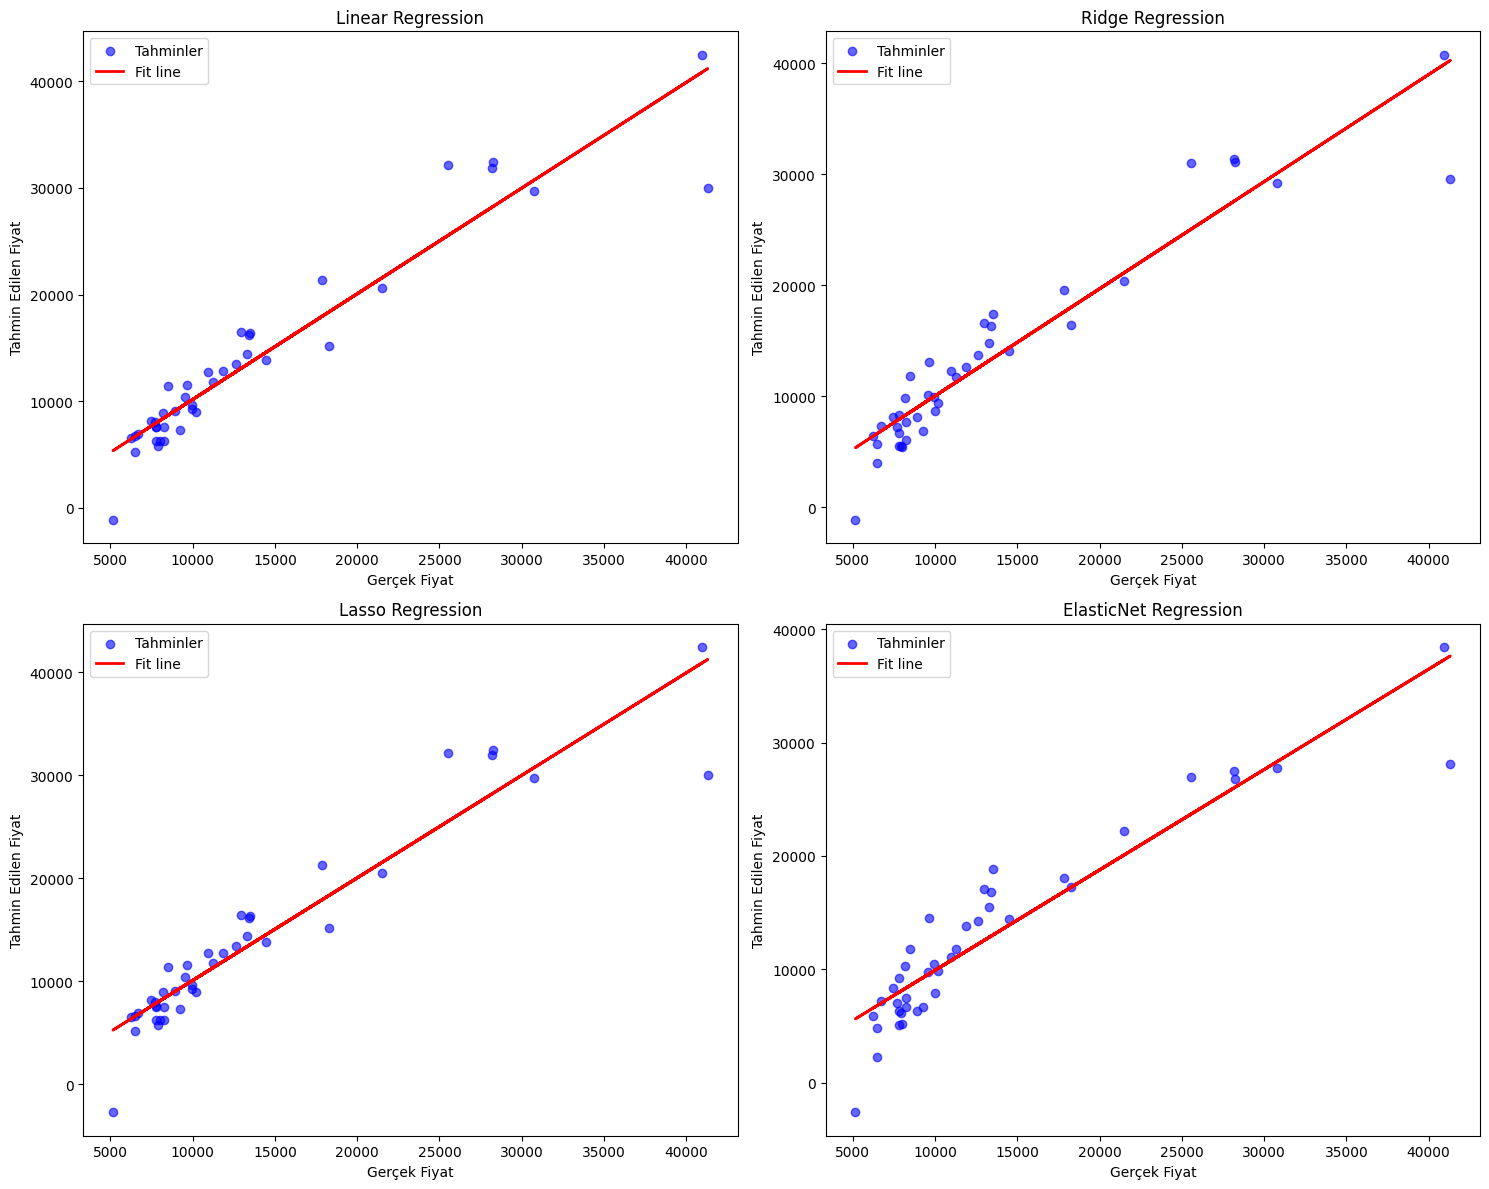

In [81]:
import matplotlib.pyplot as plt
import numpy as np

models = {
    'Linear Regression': y_pred,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'ElasticNet Regression': y_pred_elastic
}

y_true = y_test

plt.figure(figsize=(15,12))

for i, (name, y_pred_model) in enumerate(models.items(), 1):
    plt.subplot(2, 2, i)
    plt.scatter(y_true, y_pred_model, color='blue', alpha=0.6, label='Tahminler')

    z = np.polyfit(y_true, y_pred_model, 1)
    p = np.poly1d(z)
    plt.plot(y_true, p(y_true), color='red', linewidth=2, label='Fit line')

    plt.xlabel('Gerçek Fiyat')
    plt.ylabel('Tahmin Edilen Fiyat')
    plt.title(name)
    plt.legend()

plt.tight_layout()
plt.show()
